Make sure this notebook is run in order and the hardcoded range limits are adjusted based off the maximum and minimum Jpar_var and gamma_c for some equilibrium (use the 1D histograms to help)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from firm3d.plotting.plotting_helpers import plot_trajectory_poloidal

%matplotlib inline

In [2]:
FontSize = 24
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 1

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman No9 L", "Liberation Serif", "DejaVu Serif"],
})

# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
# del dict
AXES_MARGINS = dict(left=0.18, right=0.85, bottom=0.20, top=0.87) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
# AXES_MARGINS = dict(left=0.14, right=0.98, bottom=0.14, top=0.82)
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)

promptloss_thres = 2
nParticles = int(5e5)


In [3]:
# --- 1D histogram helpers (run once; used by the per-configuration cells below) ---
import numpy as np
import matplotlib.pyplot as plt

NBINS = 40
JPAR_FLOOR = 1e-3  # log axis cannot show 0; values below this go in the first bin


def _report(name, quantity, n_total, n_below):
    msg = f"{name}: {n_total} lost pure-banana EPs in the {quantity} histogram"
    if n_below:
        msg += f" ({n_below} at or below the {JPAR_FLOOR:g} floor, stacked in the first bin)"
    print(msg)


def plot_gammac_hist(gammac_mean, banana_frac, name, color="#1b6ca8", save=True,
                     nbins=NBINS, vmax=None):
    """1D histogram of gamma_c for lost pure-banana EPs of one configuration.

    Bins span 0 to the data maximum (or `vmax`, e.g. a value shared across
    configurations), so every particle lands in a real bin.
    """
    mask = banana_frac == 1
    data = np.asarray(gammac_mean)[mask]
    upper = data.max() if vmax is None else vmax
    bins = np.linspace(0, upper, nbins + 1)
    _report(name, r"gamma_c", data.size, 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    apply_standard_axes(fig)
    counts, _, _ = ax.hist(data, bins=bins, color=color, edgecolor="k", lw=0.5)
    assert counts.sum() == data.size, "some particles fell outside the bins"

    ax.set_xlabel(r"$\gamma_c$", **label_kw)
    ax.set_ylabel("Lost pure banana EP count", **label_kw)
    ax.set_title(f"{name}  (N = {data.size})", **label_kw)
    ax.set_xlim(0, upper)
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
    if save:
        fig.savefig(f"figures/hist1d_gammac_{name}.pdf", dpi=300)
    plt.show()
    return fig, ax


def plot_Jpar_var_hist(Jpar_var, banana_frac, name, color="#1b6ca8", save=True,
                       nbins=NBINS, vmax=None, floor=JPAR_FLOOR):
    """1D histogram of sqrt(<dJpar^2>)/<Jpar> for lost pure-banana EPs.

    Log-spaced bins run from `floor` to the data maximum (or `vmax`). Values at
    or below the floor (including exact zeros) are clipped into the first bin,
    so the counts still add up to every pure-banana particle.
    """
    mask = banana_frac == 1
    data = np.asarray(Jpar_var)[mask]
    upper = data.max() if vmax is None else vmax
    bins = np.logspace(np.log10(floor), np.log10(upper), nbins + 1)
    n_below = int(np.count_nonzero(data <= floor))
    _report(name, r"Jpar_var", data.size, n_below)

    fig, ax = plt.subplots(figsize=(6, 5))
    apply_standard_axes(fig)
    counts, _, _ = ax.hist(np.clip(data, floor, upper), bins=bins,
                           color=color, edgecolor="k", lw=0.5)
    assert counts.sum() == data.size, "some particles fell outside the bins"

    ax.set_xscale("log")
    ax.set_xlabel(
        r"$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $",
        **label_kw,
    )
    ax.set_ylabel("Lost pure banana EP count", **label_kw)
    ax.set_title(f"{name}  (N = {data.size})", **label_kw)
    ax.set_xlim(floor, upper)
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
    if save:
        fig.savefig(f"figures/hist1d_Jpar_var_{name}.pdf", dpi=300)
    plt.show()
    return fig, ax


QA

In [4]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QA_t1e-1/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

trapped_bool = np.array(trapped_bool)
barely_trapped_frac = np.array(barely_trapped_frac)
ripple_trapped_frac = np.array(ripple_trapped_frac)
banana_frac_QA = np.array(banana_frac)
Jpar_var_QA = np.array(Jpar_var)
nbounces = np.array(nbounces)
gammac_mean_QA = np.array(gammac_mean)
indices = np.array(indices)
timelost = np.array(timelost)
ntransitions = np.array(ntransitions)

# print(f"Number of trapped particles: {np.count_nonzero(trapped_bool)}")
# print(f"Number of passing particles: {np.count_nonzero(trapped_bool == 0)}")
# print(f"Number of barely trapped particles: {np.count_nonzero(barely_trapped_frac)}")
# print(f"Number of ripple trapped particles: {np.count_nonzero(ripple_trapped_frac)}")
# print(f"Number of pure banana particles: {np.count_nonzero(banana_frac == 1)}")
# print(f"Number of prompt losses (nbounce <= 3): {np.count_nonzero(nbounces <= 3)}")

findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.


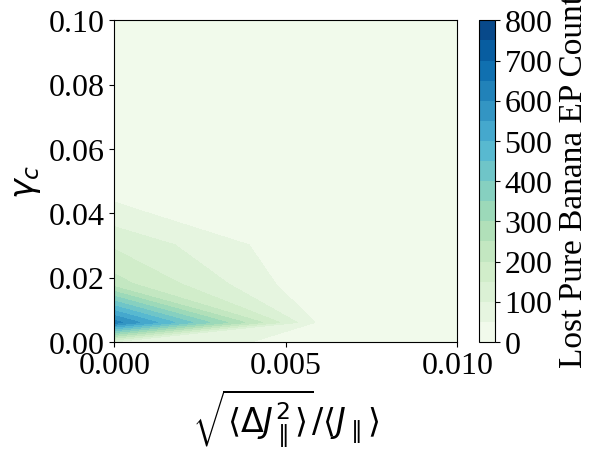

In [5]:
import numpy as np
import matplotlib.pyplot as plt

Jpar_var_banana = Jpar_var_QA[(banana_frac_QA == 1) ]
gammac_banana = gammac_mean_QA[(banana_frac_QA == 1) ]

# (Assuming gammac_banana and Jpar_var_banana are already defined)
fig, ax = plt.subplots()

# Define the maximum bounds based on your data
x_max = Jpar_var_banana.max()
y_max = gammac_banana.max()

# 1. Calculate the 2D histogram with a forced range starting at 0
H, xedges, yedges = np.histogram2d(
    Jpar_var_banana, 
    gammac_banana, 
    bins=50, 
    range=[[0, x_max], [0, y_max]]  # <--- This forces the grid to touch the axes
)

# 2. Get the center coordinates of each bin
xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
xc = np.insert(xc, 0, 0)  # Add 0 to the beginning of xc
yc = np.insert(yc, 0, 0)  # Add 0 to the beginning of yc
xc = xc[:-1]  # Remove the last element to match the shape of H
yc = yc[:-1]  # Remove the last element to match the shape of H
XI, YI = np.meshgrid(xc, yc)

# 3. Define Z as the transposed bin counts
ZI = H.T

my_levels = [0, 50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800]

# Create the filled contour background
filled_contour = ax.contourf(XI, YI, ZI, levels=my_levels, cmap='GnBu')
cbar = plt.colorbar(filled_contour, ax=ax, label='Lost EP Count')
cbar.set_label('Lost Pure Banana EP Count', size=FontSize)  # <--- Change 14 to your desired font size
cbar.ax.tick_params(labelsize=tick_labelsize)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
    
# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$', **label_kw)

# Set the limits to exactly match the plot you provided
# ax.set_xlim(0, xc[-1])
# ax.set_ylim(0, yc[-1])
ax.set_xlim(0, 0.01)
ax.set_ylim(0, 0.1)

# fig.savefig('figures/classification_diffconv_QA.pdf', dpi=300)

plt.show()

max Jpar_var QA:  [0.19933889 0.21269296 0.42322892 0.55337358 0.60890049]
max gammac QA:  0.6039950161809191
Maximum number of hits in a single box: 85


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


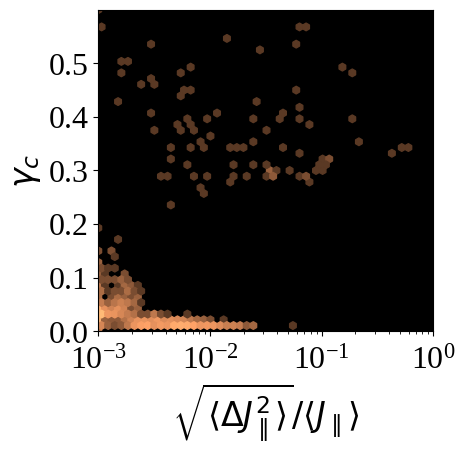

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# (Assuming your data arrays, FontSize, tick_labelsize, and label_kw are defined)

# 1. Calculate total particles from the original population
total_particles = np.count_nonzero(banana_frac_QA == 1)

# 2. CLIPPING: Instead of neglecting them, force any values below 0.001 to be exactly 0.001
# This keeps the array the exact same size and safely allows log-scaling
Jpar_var_clean = np.clip(Jpar_var_banana, a_min=0.001, a_max=None)
gammac_clean = gammac_banana  # No filtering needed here, shapes will still match perfectly

# Print out your top 5 max values from the cleaned data
top5_indices = np.argsort(Jpar_var_clean)[-5:]
print('max Jpar_var QA: ', Jpar_var_clean[top5_indices])
print('max gammac QA: ', gammac_clean.max())

fig, ax = plt.subplots(figsize=(5, 6))
apply_standard_axes(fig)

ax.set_facecolor('black')

# 3. Create weights array using the full size of the array
weights = np.ones_like(Jpar_var_clean) / total_particles

# 4. Plot the hexbin
hb = ax.hexbin(
    Jpar_var_clean, 
    gammac_clean, 
    C=weights,
    reduce_C_function=np.sum, 
    gridsize=50, 
    cmap='copper', 
    xscale='log',  
    extent=[np.log10(0.001), np.log10(0.9), 0, 0.6],
    norm=mcolors.LogNorm(vmin=1e-4, vmax=10**-1),  # <--- Dynamically log-scales the color intensity
)

# 5. Extract and print the maximum hits
max_fraction = hb.get_array().max()
max_hits = int(round(max_fraction * total_particles))
print(f"Maximum number of hits in a single box: {max_hits}")

# Set up the colorbar
cbar = plt.colorbar(hb, ax=ax, location='top', orientation='horizontal')
cbar.set_label('Fraction of Lost Pure Banana EPs', size=FontSize-2, labelpad=10)  # <--- Adjust label padding if needed
cbar.ax.tick_params(labelsize=tick_labelsize)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
ax.tick_params(axis='x', which='major', pad=7)
    
# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$', **label_kw)

# Set the limits explicitly
ax.set_xlim(0.001, 1.0)
ax.set_ylim(0, 0.6)

ax.set_yticks([0.0, 0.1, 0.2,0.3,0.4,0.5])


cbar.ax.set_visible(False)

# fig.tight_layout()
fig.savefig('figures/classification_diffconv_QA.pdf', dpi=300)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QA: 1374 lost pure-banana EPs in the gamma_c histogram


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


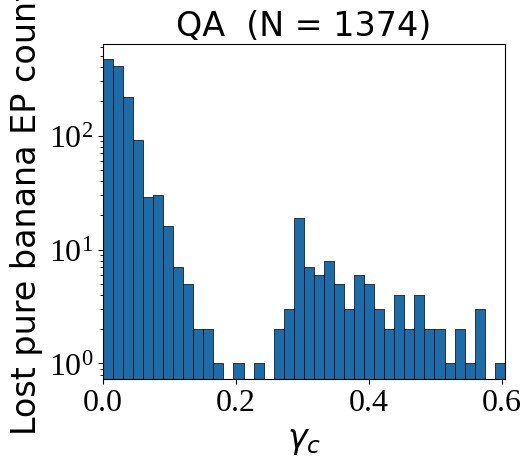

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QA: 1374 lost pure-banana EPs in the Jpar_var histogram (242 at or below the 0.001 floor, stacked in the first bin)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


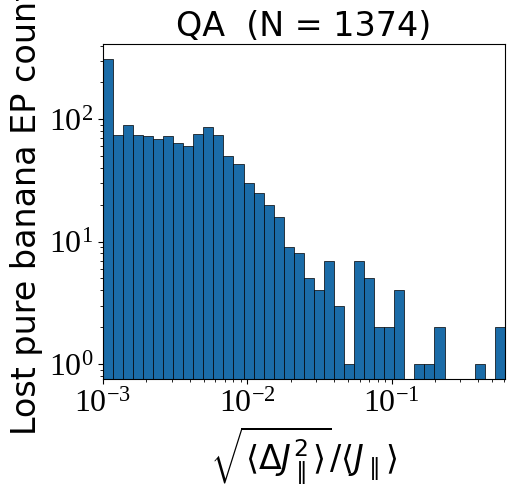

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'QA  (N = 1374)'}, xlabel='$\\sqrt{ \\langle \\Delta J_\\parallel^2 \\rangle } /\\langle J_\\parallel \\rangle $', ylabel='Lost pure banana EP count'>)

In [7]:
# 1D histograms for QA: gamma_c and normalized Jpar variation
plot_gammac_hist(gammac_mean_QA, banana_frac_QA, "QA", color="#1b6ca8")
plot_Jpar_var_hist(Jpar_var_QA, banana_frac_QA, "QA", color="#1b6ca8")


QH

In [8]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QH/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

trapped_bool = np.array(trapped_bool)
barely_trapped_frac = np.array(barely_trapped_frac)
ripple_trapped_frac = np.array(ripple_trapped_frac)
banana_frac_QH = np.array(banana_frac)
Jpar_var_QH = np.array(Jpar_var)
nbounces = np.array(nbounces)
gammac_mean_QH = np.array(gammac_mean)
indices = np.array(indices)
timelost = np.array(timelost)
ntransitions = np.array(ntransitions)

print(f"Number of trapped particles: {np.count_nonzero(trapped_bool)}")
print(f"Number of passing particles: {np.count_nonzero(trapped_bool == 0)}")
print(f"Number of barely trapped particles: {np.count_nonzero(barely_trapped_frac)}")
print(f"Number of ripple trapped particles: {np.count_nonzero(ripple_trapped_frac)}")
print(f"Number of pure banana particles: {np.count_nonzero(banana_frac == 1)}")
print(f"Number of prompt losses (nbounce <= 3): {np.count_nonzero(nbounces <= 3)}")

Number of trapped particles: 912
Number of passing particles: 0
Number of barely trapped particles: 21
Number of ripple trapped particles: 0
Number of pure banana particles: 0
Number of prompt losses (nbounce <= 3): 112


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


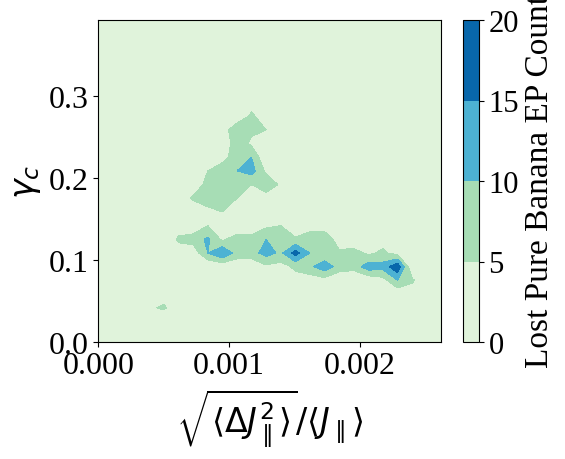

In [9]:
import numpy as np
import matplotlib.pyplot as plt

Jpar_var_banana = Jpar_var_QH[(banana_frac_QH == 1) ]
gammac_banana = gammac_mean_QH[(banana_frac_QH == 1) ]

# (Assuming gammac_banana and Jpar_var_banana are already defined)
fig, ax = plt.subplots()

# 1. Calculate the 2D histogram
x_max = Jpar_var_banana.max()
y_max = gammac_banana.max()
H, xedges, yedges = np.histogram2d(
    Jpar_var_banana, gammac_banana, bins=25, range=[[0, x_max], [0, y_max]]
)

xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
xc = np.insert(xc, 0, 0)  # Add 0 to the beginning of xc
yc = np.insert(yc, 0, 0)  # Add 0 to the beginning of yc
xc = xc[:-1]  # Remove the last element to match the shape of H
yc = yc[:-1]  # Remove the last element to match the shapeof H
XI, YI = np.meshgrid(xc, yc)
ZI = H.T

# 2. Explicitly define your levels from 0 to 5
# This caps your contour colors strictly between 0 and 5
my_levels = [0, 5, 10, 15, 20]
# my_levels = np.arange(0,ZI.max()+1)  # Create levels from 0 to max count in ZI

# Create the filled contour background using your defined levels
# We add extend='max' so any data point > 5 gets colored with the maximum color
filled_contour = ax.contourf(XI, YI, ZI, levels=my_levels, cmap='GnBu')

# 3. Create the colorbar and force the ticks to match your levels
cbar = plt.colorbar(filled_contour, ax=ax, ticks=my_levels)
cbar.set_label('Lost Pure Banana EP Count', size=FontSize) 
cbar.ax.tick_params(labelsize=FontSize - 2)

# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$',**label_kw)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)

ax.set_xlim(0, xc[-1])
ax.set_ylim(0, yc[-1])

fig.savefig('figures/classification_diffconv_QH.pdf', dpi=300)

plt.show()

In [10]:
print(ZI.sum())

779.0


findfont: Font family 'Times New Roman' not found.


Maximum number of hits in a single box: 27


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


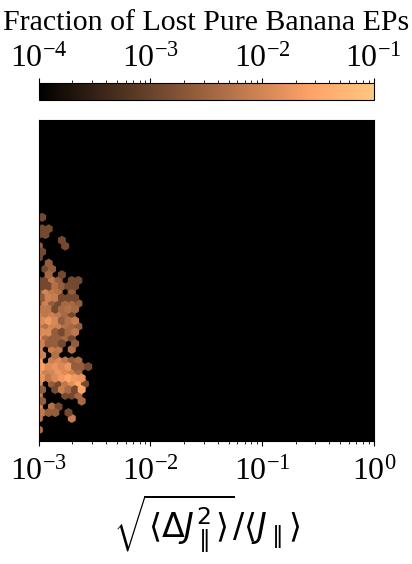

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# (Assuming your data arrays, FontSize, tick_labelsize, and label_kw are defined)

# 1. Calculate total particles from the original population
total_particles = np.count_nonzero(banana_frac_QH == 1)

# 2. CLIPPING: Instead of neglecting them, force any values below 0.001 to be exactly 0.001
# This keeps the array the exact same size and safely allows log-scaling
Jpar_var_clean = np.clip(Jpar_var_banana, a_min=0.001, a_max=None)
gammac_clean = gammac_banana  # No filtering needed here, shapes will still match perfectly

fig, ax = plt.subplots(figsize=(5, 6))
apply_standard_axes(fig)
ax.set_facecolor('black')

# 3. Create weights array using the full size of the array
weights = np.ones_like(Jpar_var_clean) / total_particles

# 4. Plot the hexbin
hb = ax.hexbin(
    Jpar_var_clean, 
    gammac_clean, 
    C=weights,
    reduce_C_function=np.sum, 
    gridsize=50, 
    cmap='copper', 
    xscale='log',  
    extent=[np.log10(0.001), np.log10(0.9), 0, 0.6],
    norm=mcolors.LogNorm(vmin=1e-4, vmax=10**-1),  # <--- Dynamically log-scales the color intensity
)

# 5. Extract and print the maximum hits
max_fraction = hb.get_array().max()
max_hits = int(round(max_fraction * total_particles))
print(f"Maximum number of hits in a single box: {max_hits}")

cbar = plt.colorbar(hb, ax=ax, location='top', orientation='horizontal')
cbar.set_label('Fraction of Lost Pure Banana EPs', size=FontSize-2.5, labelpad=10)  # <--- Adjust label padding if needed
cbar.ax.tick_params(labelsize=tick_labelsize)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
ax.tick_params(axis='x', which='major', pad=7)


    
# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$', **label_kw)

# Set the limits explicitly
ax.set_xlim(0.001, 1.0)
ax.set_ylim(0, 0.6)

ax.yaxis.set_visible(False)

# fig.tight_layout()
fig.savefig('figures/classification_diffconv_QH.pdf', dpi=300)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QH: 779 lost pure-banana EPs in the gamma_c histogram


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


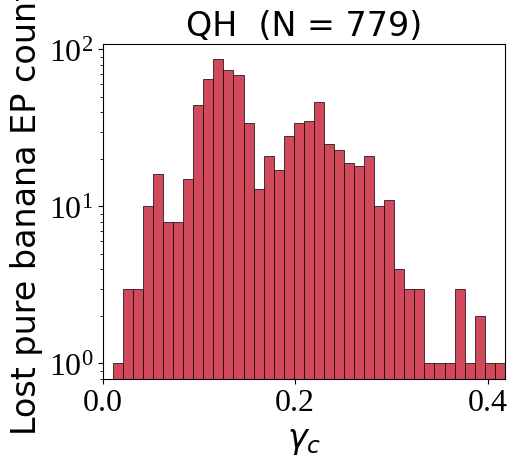

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QH: 779 lost pure-banana EPs in the Jpar_var histogram (149 at or below the 0.001 floor, stacked in the first bin)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


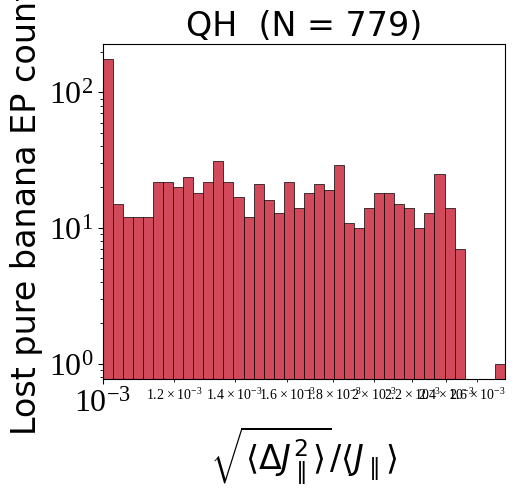

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'QH  (N = 779)'}, xlabel='$\\sqrt{ \\langle \\Delta J_\\parallel^2 \\rangle } /\\langle J_\\parallel \\rangle $', ylabel='Lost pure banana EP count'>)

In [12]:
# 1D histograms for QH: gamma_c and normalized Jpar variation
plot_gammac_hist(gammac_mean_QH, banana_frac_QH, "QH", color="#d1495b")
plot_Jpar_var_hist(Jpar_var_QH, banana_frac_QH, "QH", color="#d1495b")


QI

In [13]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QI/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

trapped_bool = np.array(trapped_bool)
barely_trapped_frac = np.array(barely_trapped_frac)
ripple_trapped_frac = np.array(ripple_trapped_frac)
banana_frac_QI = np.array(banana_frac)
Jpar_var_QI = np.array(Jpar_var)
nbounces = np.array(nbounces)
gammac_mean_QI = np.array(gammac_mean)
indices = np.array(indices)
timelost = np.array(timelost)
ntransitions = np.array(ntransitions)

print(f"Number of trapped particles: {np.count_nonzero(trapped_bool)}")
print(f"Number of passing particles: {np.count_nonzero(trapped_bool == 0)}")
print(f"Number of barely trapped particles: {np.count_nonzero(barely_trapped_frac)}")
print(f"Number of ripple trapped particles: {np.count_nonzero(ripple_trapped_frac)}")
print(f"Number of pure banana particles: {np.count_nonzero(banana_frac == 1)}")
print(f"Number of prompt losses (nbounce <= 3): {np.count_nonzero(nbounces <= 3)}")

Number of trapped particles: 177
Number of passing particles: 0
Number of barely trapped particles: 2
Number of ripple trapped particles: 7
Number of pure banana particles: 0
Number of prompt losses (nbounce <= 3): 0


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


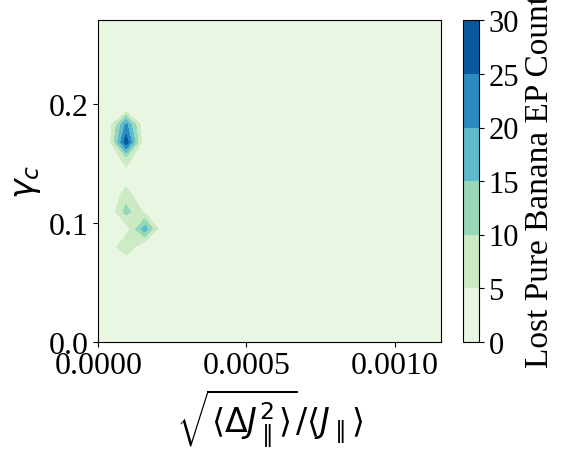

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Jpar_var_banana = Jpar_var_QI[(banana_frac_QI == 1) ]
gammac_banana = gammac_mean_QI[(banana_frac_QI == 1) ]

# (Assuming gammac_banana and Jpar_var_banana are already defined)
fig, ax = plt.subplots()

# 1. Calculate the 2D histogram
x_max = Jpar_var_banana.max()
y_max = gammac_banana.max()
H, xedges, yedges = np.histogram2d(
    Jpar_var_banana, gammac_banana, bins=20, range=[[0, x_max], [0, y_max]]
)

xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
xc = np.insert(xc, 0, 0)  # Add 0 to the beginning of xc
yc = np.insert(yc, 0, 0)  # Add 0 to
xc = xc[:-1]  # Remove the last element to match the shape of H
yc = yc[:-1]  # Remove the last element to match the shape of H
XI, YI = np.meshgrid(xc, yc)
ZI = H.T

# 2. Explicitly define your levels from 0 to 5
# This caps your contour colors strictly between 0 and 5
my_levels = [0, 5, 10, 15, 20, 25,30]

# Create the filled contour background using your defined levels
# We add extend='max' so any data point > 5 gets colored with the maximum color
filled_contour = ax.contourf(XI, YI, ZI, levels=my_levels, cmap='GnBu')

# 3. Create the colorbar and force the ticks to match your levels
cbar = plt.colorbar(filled_contour, ax=ax, ticks=my_levels)
cbar.set_label('Lost Pure Banana EP Count', size=FontSize) 
cbar.ax.tick_params(labelsize=FontSize - 2)

# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$',**label_kw)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)

ax.set_xlim(0, xc[-1])
ax.set_ylim(0, yc[-1])

fig.savefig('figures/classification_diffconv_QI.pdf', dpi=300)

plt.show()

In [15]:
ZI.sum()

np.float64(168.0)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Maximum number of hits in a single box: 38


findfont: Font family 'Times New Roman' not found.


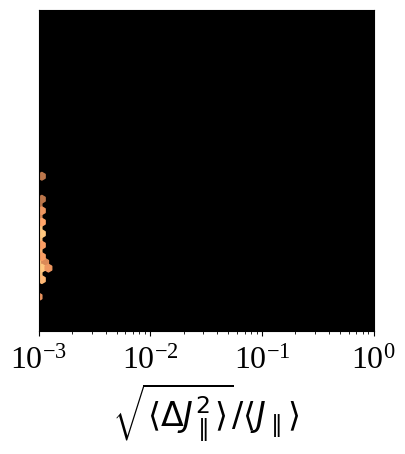

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# (Assuming your data arrays, FontSize, tick_labelsize, and label_kw are defined)

# 1. Calculate total particles from the original population
total_particles = np.count_nonzero(banana_frac_QI == 1)

# 2. CLIPPING: Instead of neglecting them, force any values below 0.001 to be exactly 0.001
# This keeps the array the exact same size and safely allows log-scaling
Jpar_var_clean = np.clip(Jpar_var_banana, a_min=0.001, a_max=None)
gammac_clean = gammac_banana  # No filtering needed here, shapes will still match perfectly

fig, ax = plt.subplots(figsize=(5, 6))
apply_standard_axes(fig)
ax.set_facecolor('black')

# 3. Create weights array using the full size of the array
weights = np.ones_like(Jpar_var_clean) / total_particles

# 4. Plot the hexbin
hb = ax.hexbin(
    Jpar_var_clean, 
    gammac_clean, 
    C=weights,
    reduce_C_function=np.sum, 
    gridsize=50, 
    cmap='copper', 
    xscale='log',  
    extent=[np.log10(0.001), np.log10(0.9), 0, 0.6],
    norm=mcolors.LogNorm(vmin=1e-4, vmax=10**-1),  # <--- Dynamically log-scales the color intensity
)

# 5. Extract and print the maximum hits
max_fraction = hb.get_array().max()
max_hits = int(round(max_fraction * total_particles))
print(f"Maximum number of hits in a single box: {max_hits}")

# Set up the colorbar
cbar = plt.colorbar(hb, ax=ax, location='top', orientation='horizontal')
cbar.set_label('Fraction of Lost Pure Banana EPs', size=FontSize-2.5, labelpad=10)  # <--- Adjust label padding if needed
cbar.ax.tick_params(labelsize=tick_labelsize)
cbar.ax.set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
    
# Set labels
ax.set_xlabel(r'$\sqrt{ \langle \Delta J_\parallel^2 \rangle } /\langle J_\parallel \rangle $', **label_kw)
ax.set_ylabel(r'$\gamma_c$', **label_kw)

# Set the limits explicitly
ax.set_xlim(0.001, 1.0)
ax.set_ylim(0, 0.6)

ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.tick_params(axis='x', which='major', pad=7)
ax.yaxis.set_visible(False)

# fig.tight_layout()
fig.savefig('figures/classification_diffconv_QI.pdf', dpi=300)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QI: 168 lost pure-banana EPs in the gamma_c histogram


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


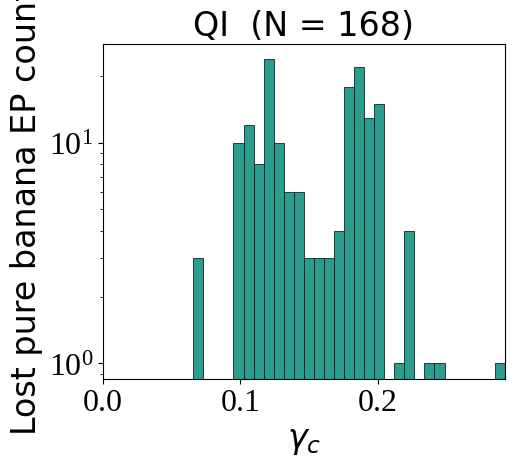

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


QI: 168 lost pure-banana EPs in the Jpar_var histogram (162 at or below the 0.001 floor, stacked in the first bin)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


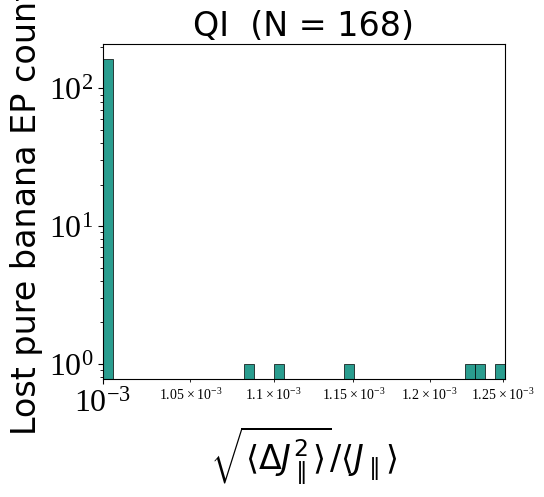

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'QI  (N = 168)'}, xlabel='$\\sqrt{ \\langle \\Delta J_\\parallel^2 \\rangle } /\\langle J_\\parallel \\rangle $', ylabel='Lost pure banana EP count'>)

In [17]:
# 1D histograms for QI: gamma_c and normalized Jpar variation
plot_gammac_hist(gammac_mean_QI, banana_frac_QI, "QI", color="#2a9d8f")
plot_Jpar_var_hist(Jpar_var_QI, banana_frac_QI, "QI", color="#2a9d8f")
